In [1]:

from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from scipy.ndimage import gaussian_filter

for fname in [
    "/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_Irefit.fits",
    "/Volumes/Crucial/astrodata/data/rcw86/radio/G315.42.3_I_CropI.fits",
    "/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_DeepRM_Crop.fits",
    "/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_ShallowRM.fits",
]:
    with fits.open(fname) as hdul:
        hdr0 = hdul[0].header
        print(f"{fname}: NAXIS = {hdr0['NAXIS']}")
        if hdr0['NAXIS'] >= 3:
            print("  CTYPE3 =", hdr0.get('CTYPE3'))
            print("  CRVAL3 =", hdr0.get('CRVAL3'), hdr0.get('CDELT3'), hdr0.get('CRPIX3'))
        print()



/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_Irefit.fits: NAXIS = 4
  CTYPE3 = SPECLNMF
  CRVAL3 = 1335300000.0 57551080.0 1.0

/Volumes/Crucial/astrodata/data/rcw86/radio/G315.42.3_I_CropI.fits: NAXIS = 4
  CTYPE3 = SPECLNMF
  CRVAL3 = 1335299968.0 57551080.0 1.0

/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_DeepRM_Crop.fits: NAXIS = 4
  CTYPE3 = MaxRMSyn
  CRVAL3 = 299792456578.5 1.0 1.0

/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_ShallowRM.fits: NAXIS = 4
  CTYPE3 = MaxRMSyn
  CRVAL3 = 299792456578.5 1.0 1.0



In [2]:
ire_fits_file = "/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_Irefit.fits"
with fits.open(ire_fits_file) as ffile:
    hdu = ffile[0]
    data4d = hdu.data
    header = hdu.header

data3d = np.squeeze(data4d)

slice0 = data3d[0,:,:]
slice1 = data3d[1,:,:]
slice2 = data3d[2,:,:]
slice3 = data3d[3,:,:]
slice4 = data3d[4,:,:]

# arr.shape == (ny, nx)
ny, nx = slice0.shape

# crop 1000 pixels from top, bottom, left, right
cropped0 = slice0[1800 : ny-1800,   1800 : nx-1800]
cropped1 = slice1[1800 : ny-1800,   1800 : nx-1800] 

wcs = WCS(header)

wcs4 = WCS(header)
wcs2 = wcs4.celestial
y0, y1 = 1800, ny-1800
x0, x1 = 1800, nx-1800
wcs2_cut = wcs2.slice((slice(y0, y1), slice(x0, x1)))
wcs2_cut

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN' 
CRVAL : 220.75 -62.5 
CRPIX : 1190.0 1190.0 
NAXIS : 2379  2379

In [3]:

wcs2d = wcs.celestial
wcs2d


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---SIN' 'DEC--SIN' 
CRVAL : 220.75 -62.5 
CRPIX : 2990.0 2990.0 
NAXIS : 5979  5979

In [4]:

data3d = np.squeeze(data4d)
data3d.shape


(5, 5979, 5979)

In [5]:

slice0 = data3d[0,:,:]
slice1 = data3d[1,:,:]
slice2 = data3d[2,:,:]
slice3 = data3d[3,:,:]
slice4 = data3d[4,:,:]

# arr.shape == (ny, nx)
ny, nx = slice0.shape

# crop 1000 pixels from top, bottom, left, right
cropped0 = slice0[1800 : ny-1800,   1800 : nx-1800]
cropped1 = slice1[1800 : ny-1800,   1800 : nx-1800] 


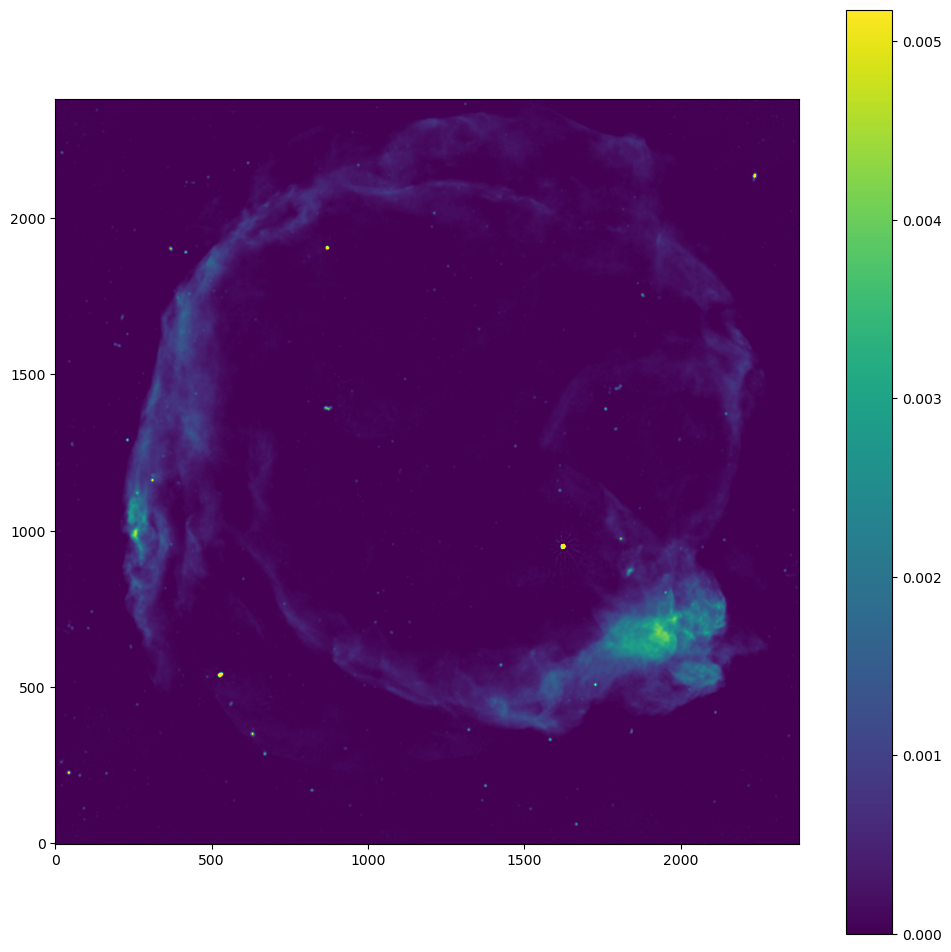

In [6]:

plt.figure(figsize=(12,12))
plt.imshow(
    cropped0, 
    #vmin = np.nanmin(slice0), 
    vmin = 0,
    vmax = abs(np.nanmin(slice0)),
    origin='lower',
)
plt.colorbar()
plt.show()
#plt.savefig("0channel2.png", dpi = 500)


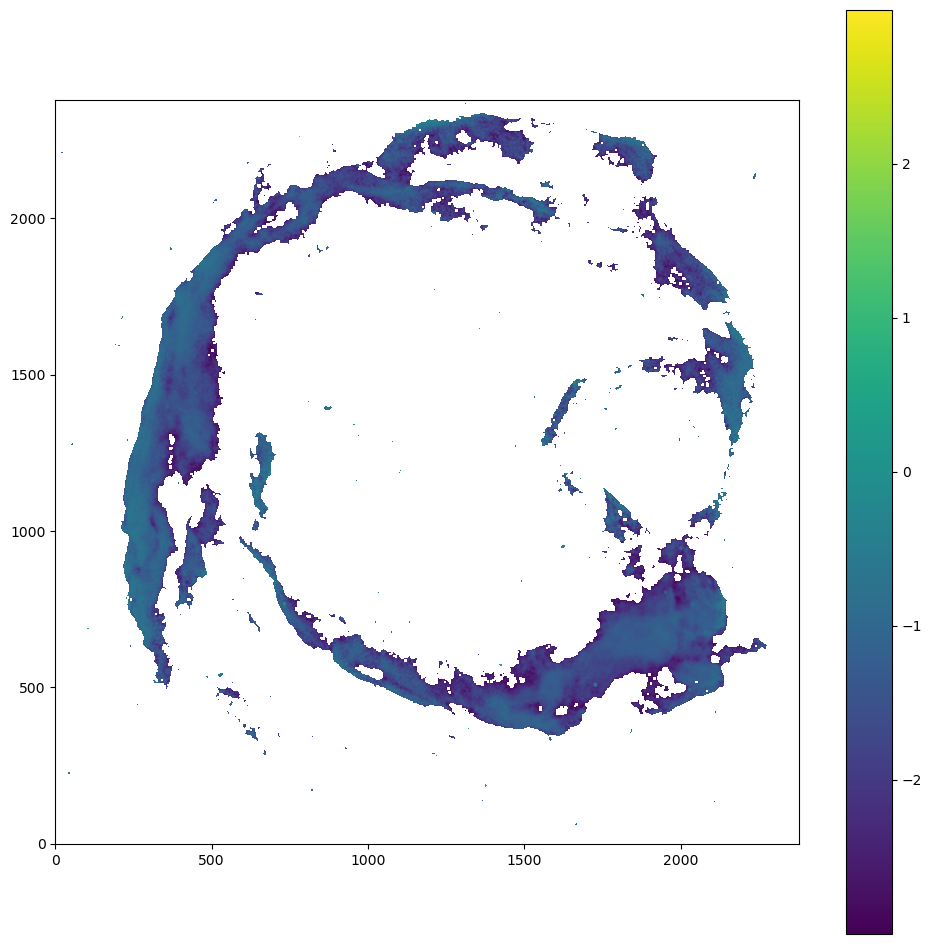

In [7]:

plt.figure(figsize=(12,12))
plt.imshow(
    cropped1,
    origin='lower',
    #vmin = np.nanmin(slice0), 
    #vmin = 0,
    #vmax = abs(np.nanmin(slice1))
)
plt.colorbar()
plt.show()
#plt.savefig("0channel2.png", dpi = 500)


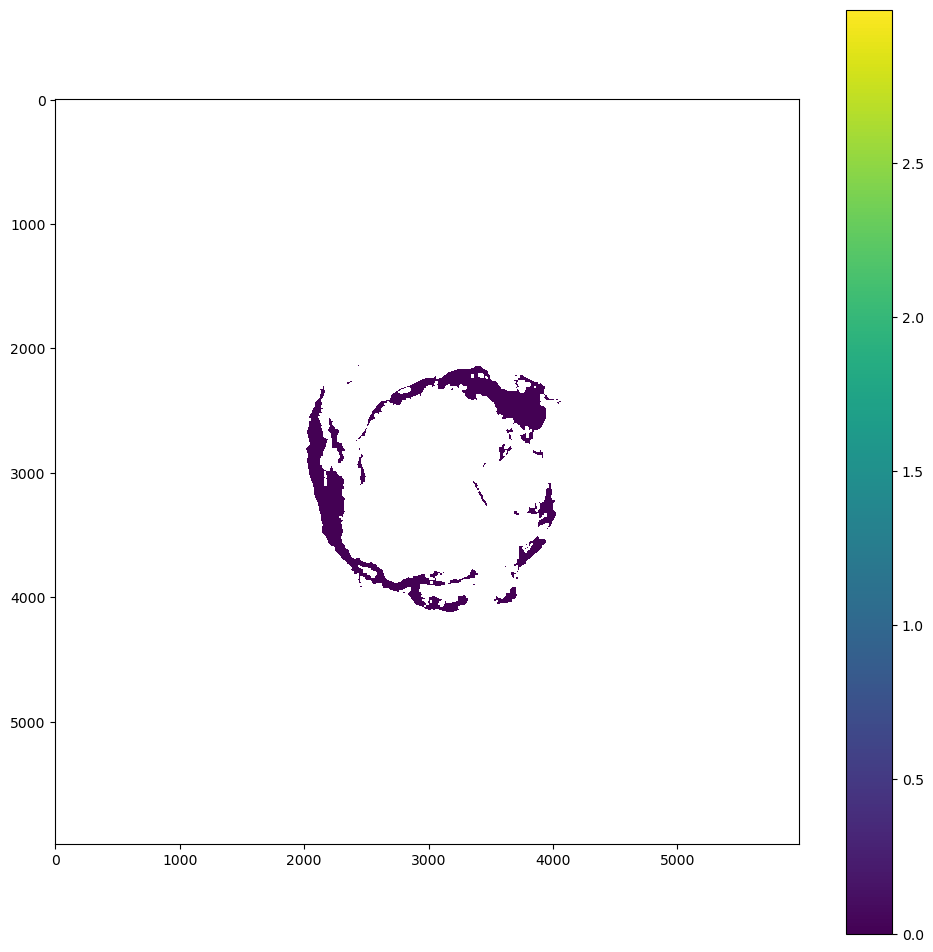

In [8]:

plt.figure(figsize=(12,12))
plt.imshow(
    slice1, 
    vmin = 0, 
    vmax = abs(np.nanmin(slice1))
)
plt.colorbar()
plt.show()
#plt.savefig("1channel.png", dpi = 200)

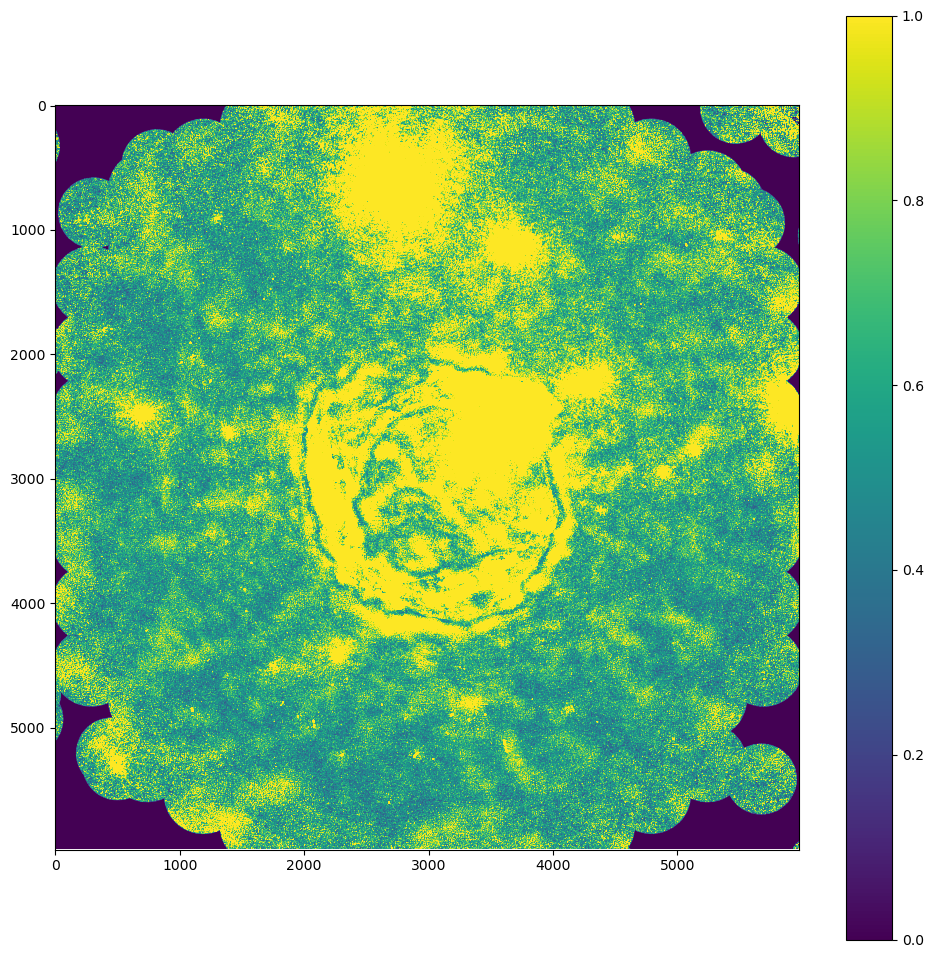

In [9]:

plt.figure(figsize=(12,12))
plt.imshow(
    slice4, 
    vmin = 0, 
    vmax = abs(np.nanmin(slice4))
)
plt.colorbar()
plt.show()
#plt.savefig("0channel2.png", dpi = 200)

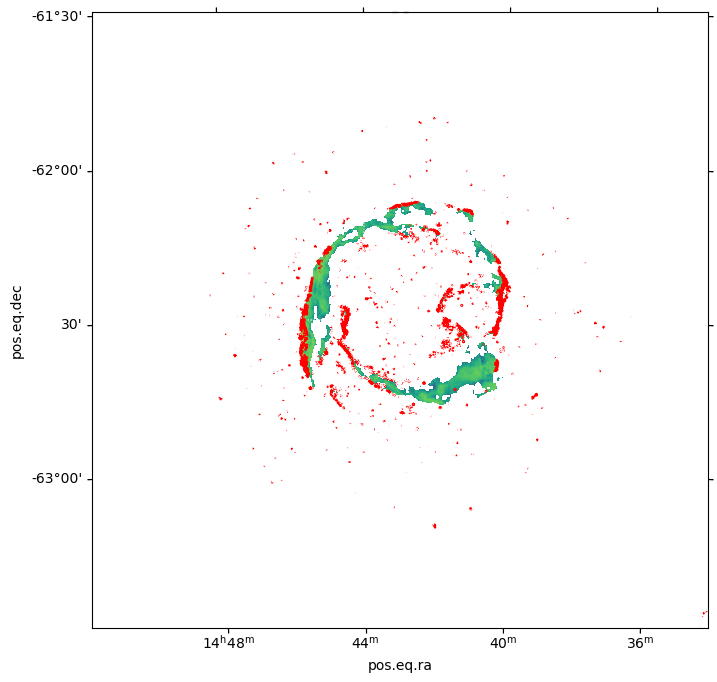

In [10]:

vmin, vmax = np.nanpercentile(slice1, [5,99])
levels = [(vmin + (vmax - vmin)*f) for f in [0.8, 0.9]]
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=wcs2d)

norm = simple_norm(slice1, 'sqrt', percent=99.5)
ax.imshow(slice1, norm=norm)

contours = ax.contour(slice1, levels = levels, colors = 'red')
ax.set_label('RA')
ax.set_label('dec')
plt.grid(color='white', ls='dotted')
plt.show()

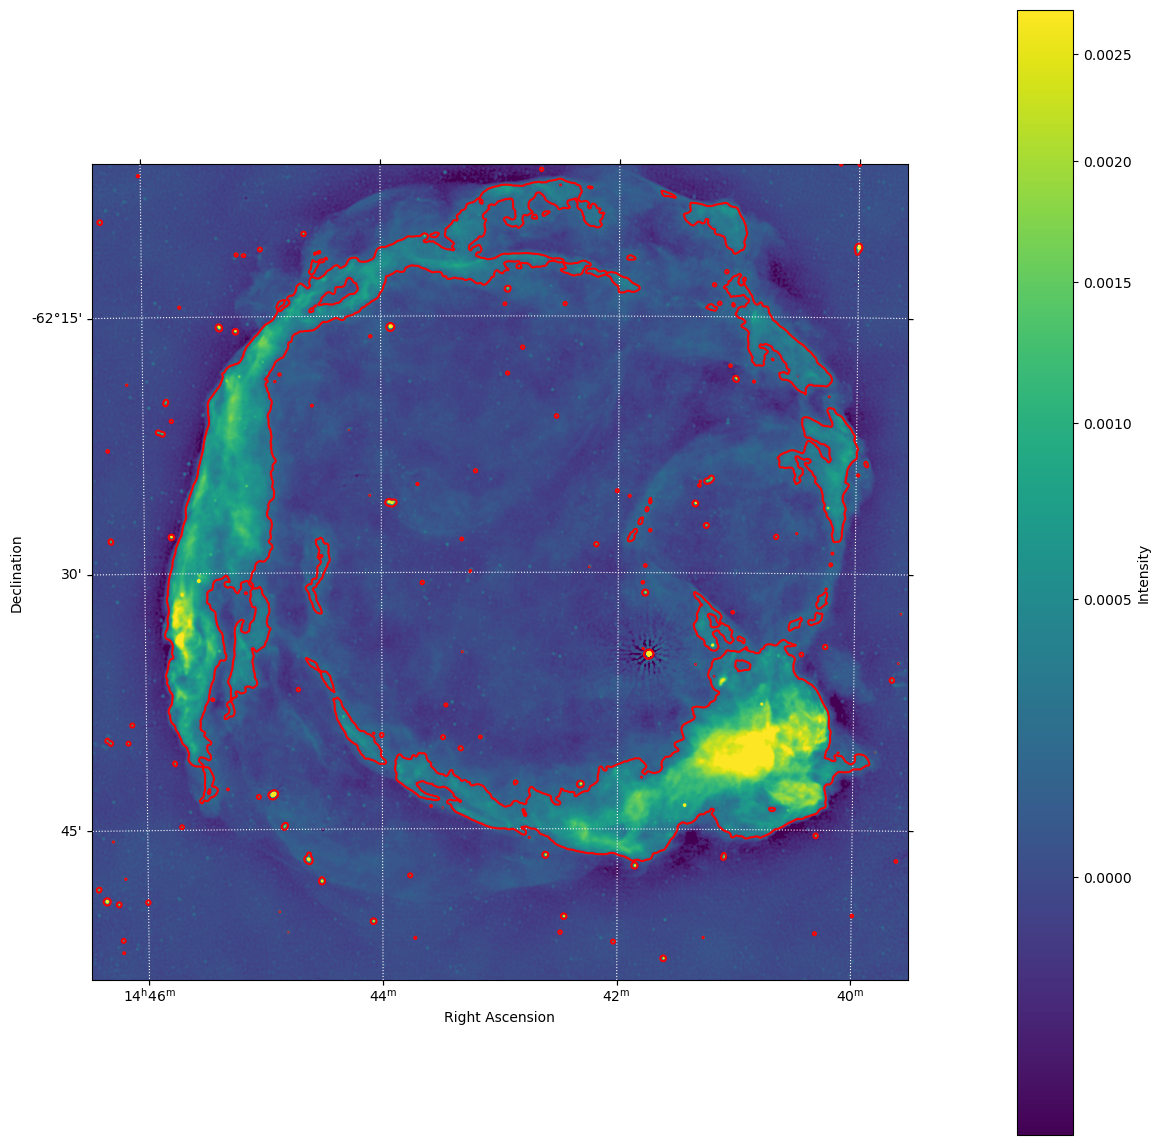

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.convolution import convolve, Gaussian2DKernel

plot_slice = cropped0

# 1) compute min/max of the map (ignore NaNs)
min_val = np.nanmin(plot_slice)
max_val = np.nanmax(plot_slice)


levels = [0.0002]

# 3) plot image + contours
fig = plt.figure(figsize=(12,12))
ax  = fig.add_subplot(1,1,1, projection=wcs2_cut)

# show the map with a sqrt stretch for visibility
norm = simple_norm(plot_slice, 'sqrt', percent=99.5)
im = ax.imshow(plot_slice, norm=norm, origin='lower')

# now add a colorbar using plt.colorbar (or fig.colorbar)
cbar = plt.colorbar(im, ax=ax, pad=0.1)
cbar.set_label('Intensity')
# draw the %-level contours

# build a 2D Gaussian kernel with a given FWHM or sigma
kernel = Gaussian2DKernel(x_stddev=3)   # sigma=2 px

# convolve, automatically handles NaNs (you can set boundary behavior)
smoothed = convolve(plot_slice, kernel, boundary='extend')

cs = ax.contour(
    smoothed,
    levels=levels,
    colors=['red','red','red'],  # one color per level
    linewidths=1.5,
    origin='lower'
)

# clean up axes
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.grid(color='white', ls='dotted')
plt.tight_layout()
plt.show()

# Fermi LAT

In [12]:
fermi_file = '/Volumes/Crucial/astrodata/data/rcw86/gamma/TSmap_2008-2025_PSF1-3.fits'
with fits.open(fermi_file) as ffile:
    hdu = ffile[0]
    fermi_data = hdu.data
    fermi_header = hdu.header


wcs_fermi = WCS(fermi_header)
wcs_fermi
crop = 130
ny, nx = fermi_data.shape
print(nx, ny)
# crop 1000 pixels from top, bottom, left, right
cropped_fermi = fermi_data[crop-5 : ny-crop+5,   crop-10 : nx-crop] 
print(cropped_fermi.shape)
wcs_fermi_cropped = wcs_fermi.slice((slice(crop-5, ny-crop+5), slice(crop-10, nx-crop)))
wcs_fermi_cropped

300 300
(50, 50)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---AIT' 'DEC--AIT' 
CRVAL : 220.121 -62.645 
CRPIX : 30.5 25.5 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.05 0.05 
NAXIS : 50  50

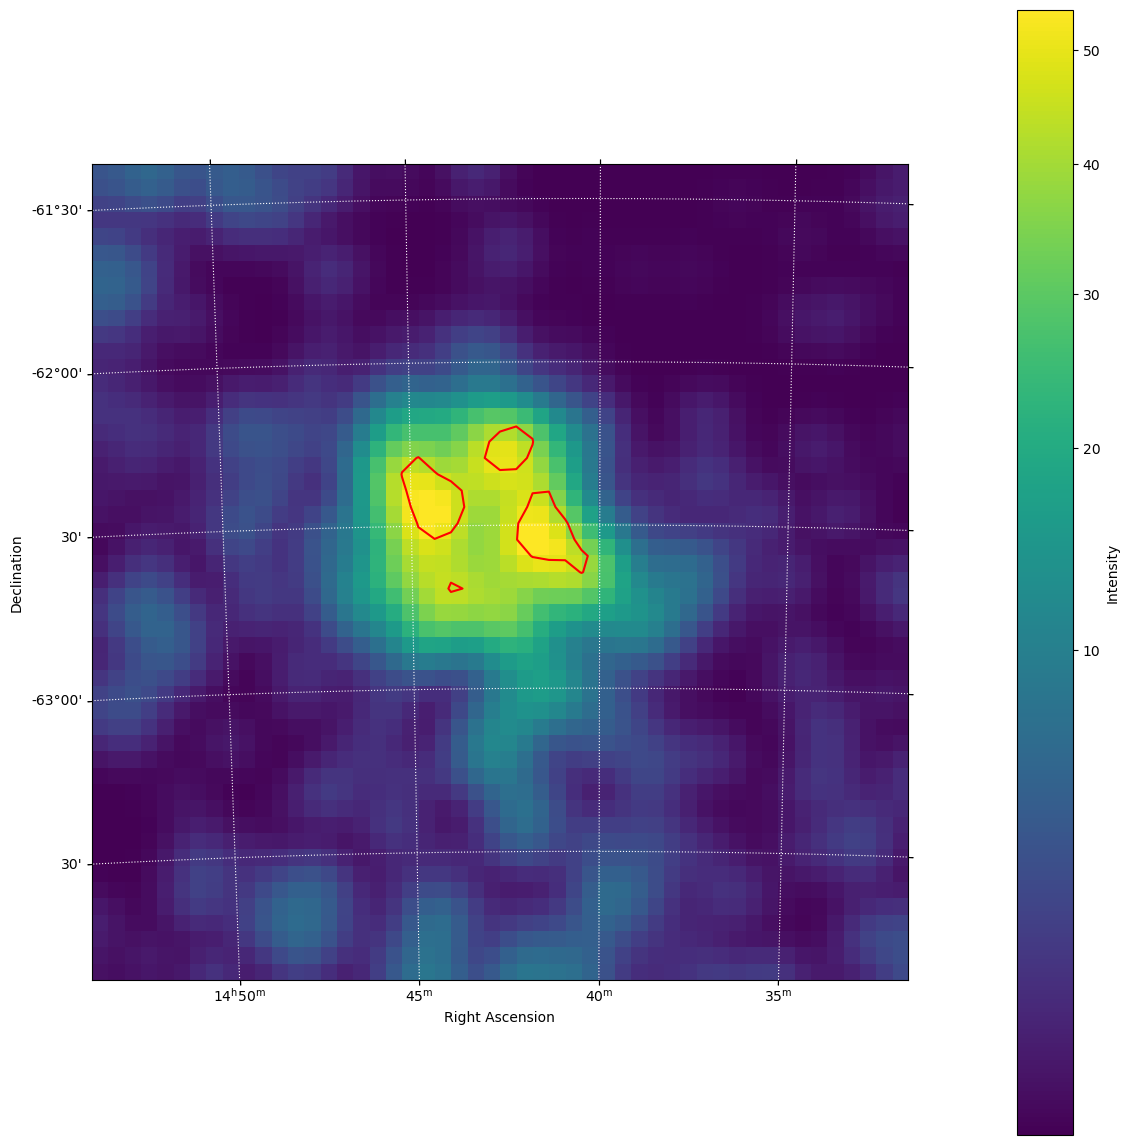

In [13]:
levels = [50]
plot_slice = cropped_fermi

# pick a Gaussian σ in pixels (tweak to taste)
sigma_pix = 1.0

# temporarily fill NaNs (so the filter doesn’t spread zeros)
# then restore them afterwards
median_val = np.nanmedian(plot_slice)
tmp = np.nan_to_num(plot_slice, nan=median_val)
smoothed = gaussian_filter(tmp, sigma=sigma_pix)
smoothed[np.isnan(plot_slice)] = np.nan

# now plot that instead of the raw map
fig = plt.figure(figsize=(12,12))
ax  = fig.add_subplot(1,1,1, projection=wcs_fermi_cropped)

norm = simple_norm(smoothed, 'sqrt', percent=99.5)
im   = ax.imshow(smoothed, norm=norm, origin='lower')

cbar = plt.colorbar(im, ax=ax, pad=0.1)
cbar.set_label('Intensity')

# build a 2D Gaussian kernel with a given FWHM or sigma
kernel = Gaussian2DKernel(x_stddev=2)   # sigma=2 px

# convolve, automatically handles NaNs (you can set boundary behavior)
smoothed = convolve(plot_slice, kernel, boundary='extend')

cs = ax.contour(
    plot_slice,
    levels=levels,
    colors=['red','red','red'],  # one color per level
    linewidths=1.5,
    origin='lower'
    
)

# clean up axes
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.grid(color='white', ls='dotted')
plt.tight_layout()
plt.show()

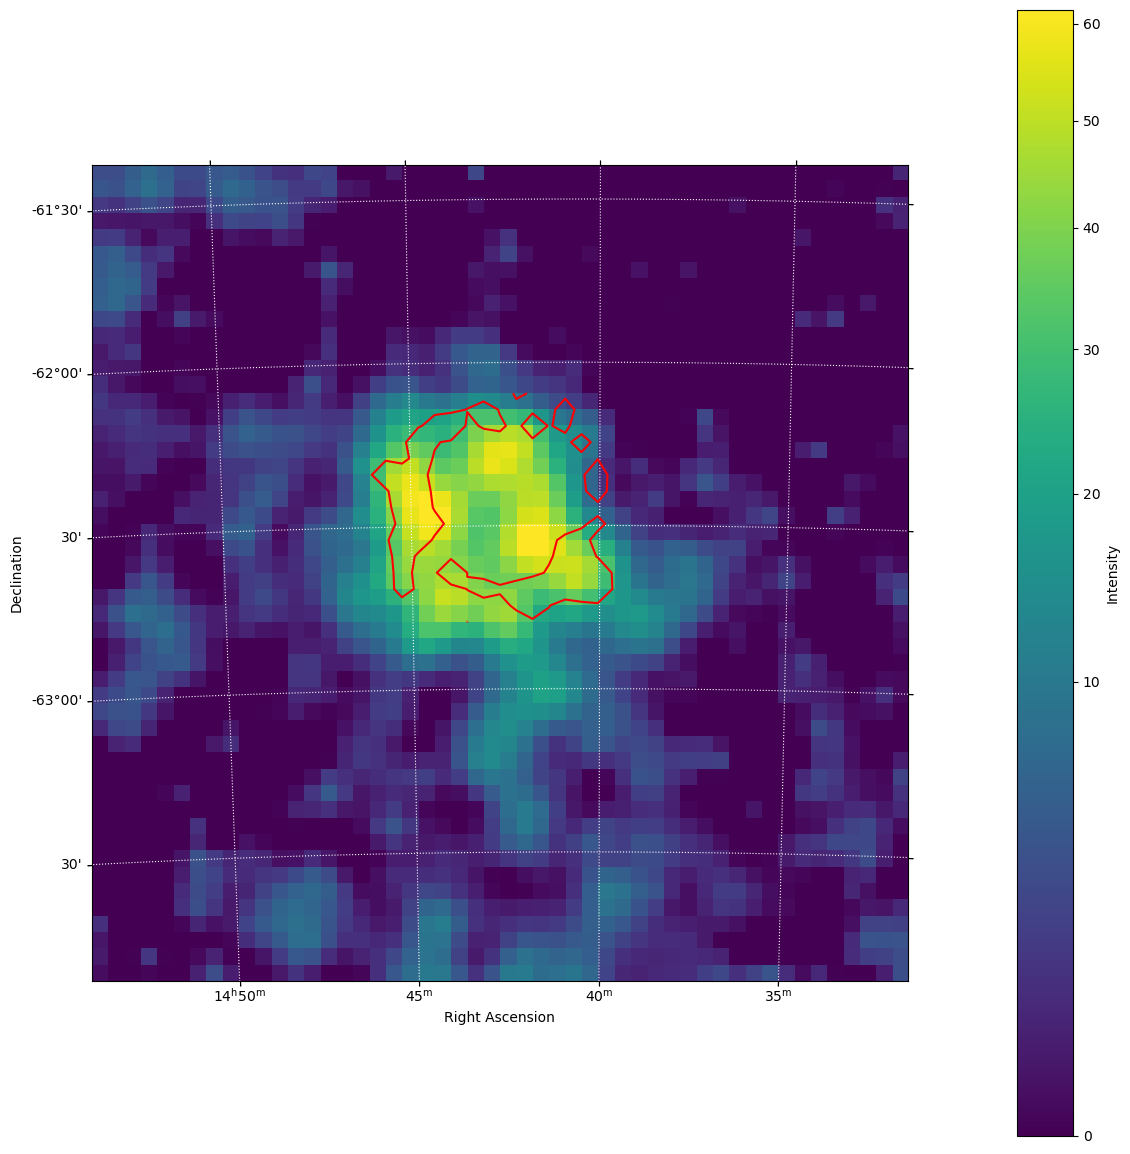

In [14]:
from reproject import reproject_interp

# cropped_fermi[cropped_fermi < 25] = 20

map1_on2, footprint = reproject_interp(
    (cropped0, wcs2_cut),
    wcs_fermi_cropped,
    shape_out=cropped_fermi.shape
)

levels = [0.0001]

fig = plt.figure(figsize=(12,12))
ax  = fig.add_subplot(1,1,1, projection=wcs_fermi_cropped)
norm2 = simple_norm(cropped_fermi, 'sqrt', percent=99.5)
im = ax.imshow(cropped_fermi, origin='lower', norm=norm2)

cbar = plt.colorbar(im, ax=ax, pad=0.1)
cbar.set_label('Intensity')

cs = ax.contour(
    map1_on2,
    levels=levels,
    colors=['red'],
    linewidths=1.5,
    origin='lower'
)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.grid(color='white', ls='dotted')
plt.tight_layout()
plt.show()

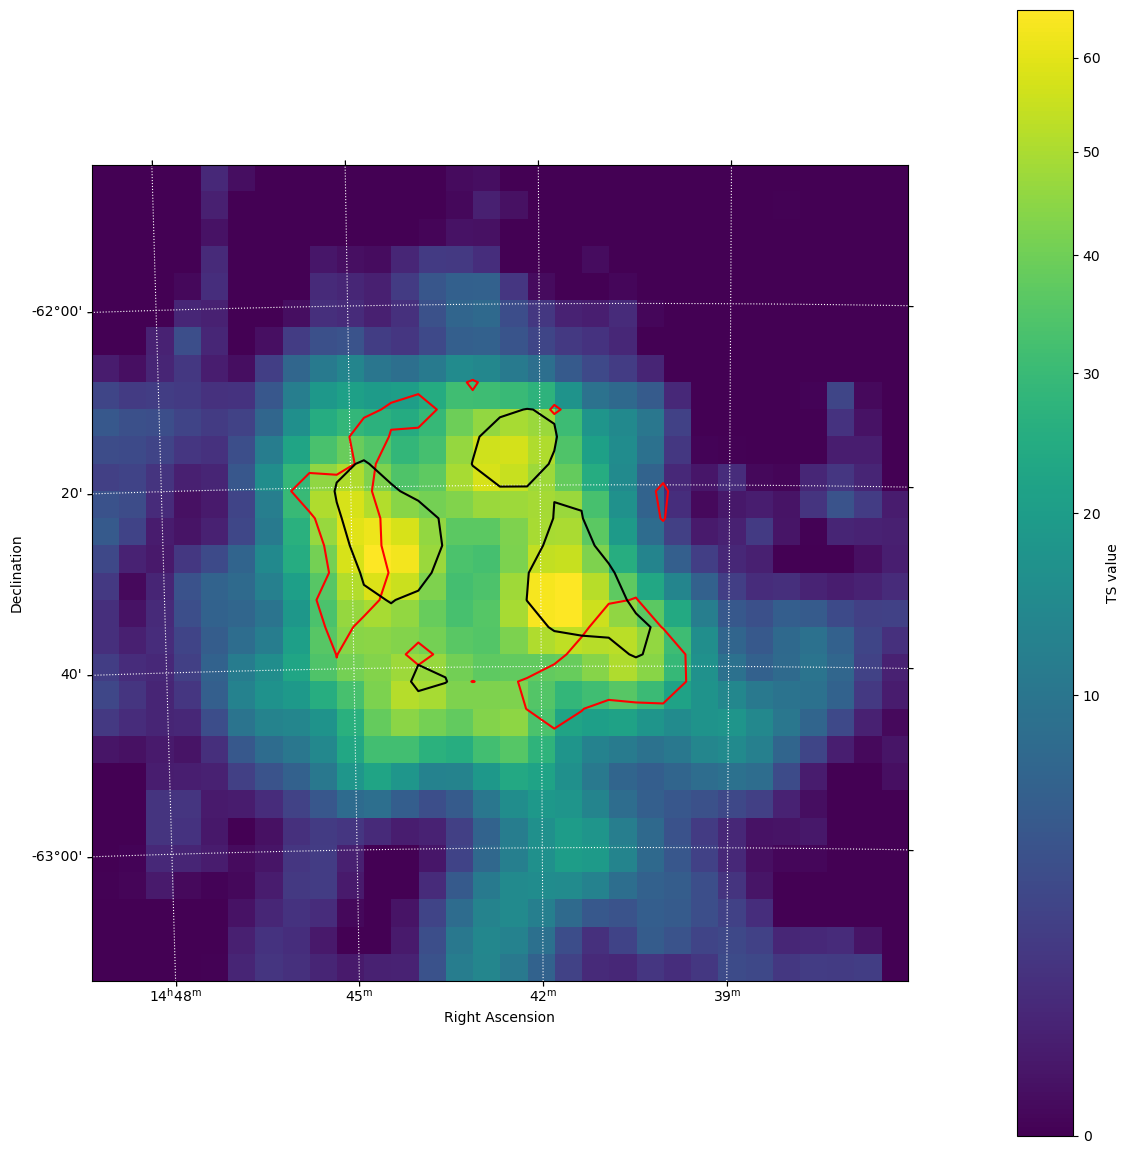

In [89]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from reproject import reproject_interp

# --- 1) First map: radio Irefit ---
ire_fits_file = "/Volumes/Crucial/astrodata/data/rcw86/radio/G315.4-2.3_Irefit.fits"
with fits.open(ire_fits_file) as f:
    hdr0  = f[0].header
    data4 = f[0].data

# squeeze out singleton spectral/Stokes axes
data3 = np.squeeze(data4)      # now shape e.g. (5, ny, nx)
slice0 = data3[0]              # pick the first plane
ny0, nx0 = slice0.shape

# crop 1800 pixels on each side
y0, y1 = 1800, ny0-1800
x0, x1 = 1800, nx0-1800
cropped0 = slice0[y0:y1, x0:x1]

# build & slice the celestial WCS
wcs4    = WCS(hdr0)
wcs2    = wcs4.celestial
wcs2_cut = wcs2.slice((slice(y0,y1), slice(x0,x1)))


# --- 2) Second map: Fermi TS map ---
fermi_file = '/Volumes/Crucial/astrodata/data/rcw86/gamma/TSmap_2008-2025_PSF1-3.fits'
with fits.open(fermi_file) as f:
    hdr1       = f[0].header
    fermi_data = f[0].data

ny1, nx1 = fermi_data.shape

# # Working system
# crop = 130
# y0f, y1f = crop-5, ny1-crop+5
# x0f, x1f = crop-10, nx1-crop

crop = 135
y0f, y1f = crop+3, ny1-crop+3
x0f, x1f = crop-5, nx1-crop-5


cropped_fermi = fermi_data[y0f:y1f, x0f:x1f]

# slice its WCS
wcs_fermi       = WCS(hdr1)
wcs_fermi_cut   = wcs_fermi.slice((slice(y0f,y1f), slice(x0f,x1f)))


# --- 3) Reproject radio → Fermi grid ---
map0_on_fermi, footprint = reproject_interp(
    (cropped0, wcs2_cut),
    wcs_fermi_cut.to_header(),
    shape_out=cropped_fermi.shape
)


# --- 4) Plot Fermi + radio contours ---
fig = plt.figure(figsize=(12,12))
ax  = fig.add_subplot(1,1,1, projection=wcs_fermi_cut)

# show Fermi TS map
norm_fermi = simple_norm(cropped_fermi, 'sqrt', percent=99.5)
im = ax.imshow(cropped_fermi,
               origin='lower',
               norm=norm_fermi,
               cmap='viridis')

cbar = fig.colorbar(im, ax=ax, pad=0.1)
cbar.set_label("TS value")

# overlay radio contours at, e.g., 50% of dynamic range
valid = (footprint>0) & np.isfinite(map0_on_fermi)
vmin, vmax = map0_on_fermi[valid].min(), map0_on_fermi[valid].max()
levels = [0.0002]

# build a 2D Gaussian kernel with a given FWHM or sigma
kernel = Gaussian2DKernel(x_stddev=0.5)   # sigma=2 px

# convolve, automatically handles NaNs (you can set boundary behavior)
smoothed = convolve(map0_on_fermi, kernel, boundary='extend')

cs = ax.contour(
    smoothed,
    levels=levels,
    colors='red',
    linewidths=1.5,
    origin='lower',
    transform=ax.get_transform(wcs_fermi_cut)
)
#ax.clabel(cs, fmt={levels[0]: "0.1 $mJy$"}, inline=True, colors='white')

cs = ax.contour(
    cropped_fermi,
    levels=[49],
    colors='black',
    linewidths=1.5,
    origin='lower',
    transform=ax.get_transform(wcs_fermi_cut)
)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.grid(color='white', ls='dotted')
plt.tight_layout()
plt.show()

In [21]:
levels

[0.0011260485243050687]